In [7]:
import sys
from pathlib import Path

parent_folder = Path.cwd().parent
if str(parent_folder) not in sys.path:
    sys.path.append(str(parent_folder))
    
import warnings
warnings.filterwarnings('ignore')

import scienceplots

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('science')
import analysis_functional as a

In [8]:
from types import SimpleNamespace


res = a.load_simulation('data/functional_test.h5')

Text(0, 0.5, '$x$ / m')

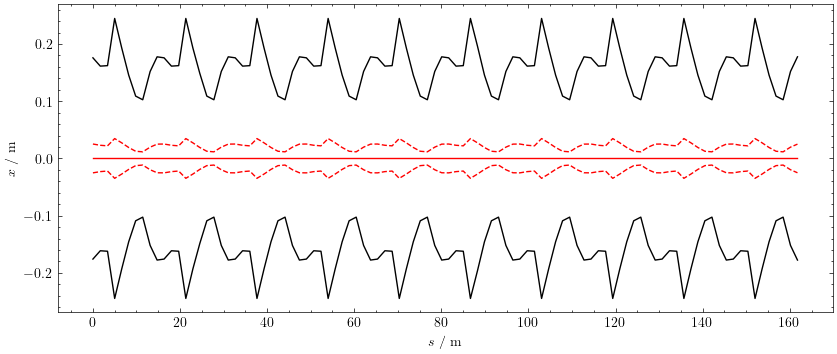

In [9]:
turn=1

#x_mean = np.mean(res.x[(turn-1)*res.n_monitors : turn*res.n_monitors], axis=1)
#x_std = np.std(res.x[(turn-1)*res.n_monitors : turn*res.n_monitors], axis=1)

fig, ax = plt.subplots(figsize=(10,4))
    
ax.plot(res.aperture_df['s'], res.aperture_df['x'].values + res.aperture_df['Lx'].values, c='k', label='Beam Pipe')
ax.plot(res.aperture_df['s'], res.aperture_df['x'].values - res.aperture_df['Lx'].values, c='k')
ax.plot(res.aperture_df['s'], res.beam_df['x0'].values + res.beam_df['sigma_x'].values, c='r', ls='--', label=r'$1\sigma$ (from Twiss)')
ax.plot(res.aperture_df['s'], res.beam_df['x0'].values - res.beam_df['sigma_x'].values, c='r', ls='--',)
ax.plot(res.aperture_df['s'], res.beam_df['x0'].values, c='r', label='Closed orbit')
#ax.plot(twiss_df_at_mon['s'], x_mean)
#ax.plot(twiss_df_at_mon['s'], x_mean+x_std)
#ax.plot(twiss_df_at_mon['s'], x_mean-x_std)
ax.set_xlabel('$s$ / m')
ax.set_ylabel('$x$ / m')

In [10]:
res.n_turns

np.int64(200)

In [11]:
Qx, Qy = a.get_tunes(res.x, res.y, res.px, res.py, res.twiss_df_at_mon, res.survivor_mask)

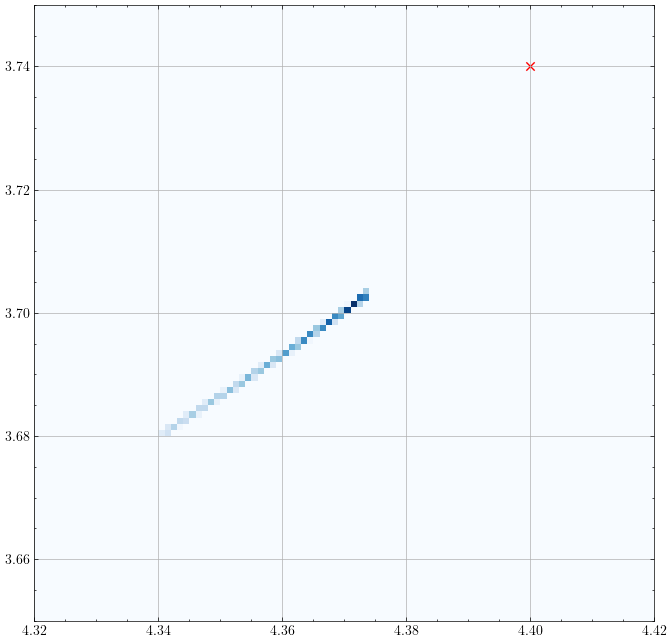

In [16]:
fig, ax = plt.subplots(figsize=(8,8))

ax.hist2d(Qx, Qy, bins=100, cmap='Blues', range=[(4.32,4.42), (3.65,3.75)])
ax.scatter(res.qx, res.qy, marker='x', c='r', label='Bare tune')
ax.grid()
plt.show()

Text(0, 0.5, '$Q_y$')

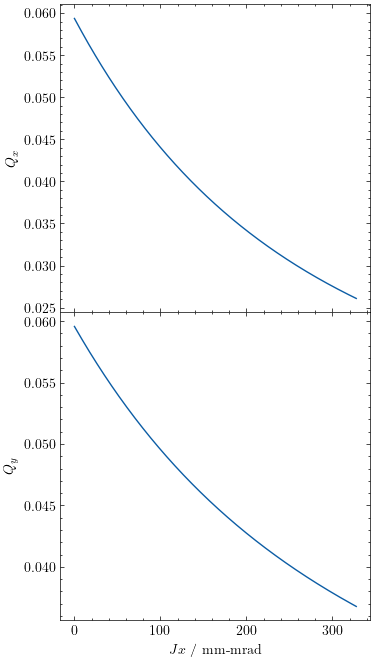

In [27]:
gamx = 0.13112848113527537 # gamma at 0
Jx_max = gamx * 0.05**2
Jx = np.linspace(0, Jx_max, 500)

fig, axs = plt.subplots(2, figsize=(4,8), sharex=True)
fig.subplots_adjust(hspace=0)
axs[0].plot(Jx*1e6, res.qx-Qx)
axs[1].plot(Jx*1e6, res.qy-Qy)

axs[1].set_xlabel('$Jx$ / mm-mrad')
axs[0].set_ylabel('$Q_x$')
axs[1].set_ylabel('$Q_y$')